# Práctica 2 — Generación de Variables Aleatorias Continuas
**CC2017 Modelación y Simulación — Ciclo 2, 2026**

Notebook único de solución y verificación numérica. Todas las simulaciones usan una semilla global reproducible. Cada estimación Monte Carlo se contrasta contra su valor exacto —forma cerrada cuando existe, cuadratura de alta precisión en caso contrario— y se reporta la desviación en unidades de error estándar.

## 0. Configuración común

In [1]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, special, stats
from IPython.display import display

SEMILLA = 20_172_026
rng = np.random.default_rng(SEMILLA)

NAVY = "#003865"
ORANGE = "#FC4C02"
GREY = "#696969"
YELLOW = "#FDB92E"
PALETA = [NAVY, ORANGE, GREY, YELLOW]

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)


def tabla(df, decimales=6):
    # Tabla uniforme, sin índice, con formato numérico homogéneo.
    return df.style.hide(axis="index").format(precision=decimales, thousands=",")


def z_desviacion(estimacion, exacto, se):
    return (estimacion - exacto) / se if se > 0 else np.nan


def se_media(x):
    x = np.asarray(x, dtype=float)
    return x.std(ddof=1) / np.sqrt(x.size)


def se_proporcion(p_hat, n):
    return math.sqrt(p_hat * (1 - p_hat) / n)

print(f"Semilla global: {SEMILLA}")

Semilla global: 20172026


## 1. Ejercicio 1

**Enunciado.** Sea $X\sim\text{Exp}(1)$. Simular la condicional de $X$ dado $X<0.05$, cuya densidad es
$$f(x)=\frac{e^{-x}}{1-e^{-0.05}},\qquad 0<x<0.05 .$$
Generar 1000 variables y estimar $E[X\mid X<0.05]$; luego obtener el valor exacto.

**Método.** El camino ingenuo —generar exponenciales y descartar las que superen $0.05$— acepta con probabilidad $1-e^{-0.05}=0.04877$, es decir **20.5 exponenciales por variable aceptada**. En su lugar se usa transformación inversa sobre la condicional, que es exacta y cuesta **un solo uniforme**:
$$F(x)=\frac{1-e^{-x}}{1-e^{-0.05}}\ \Longrightarrow\ X=F^{-1}(U)=-\log\!\bigl(1-U(1-e^{-0.05})\bigr).$$

**Valor exacto.** Integrando por partes en $\int_0^a x e^{-x}dx=1-(1+a)e^{-a}$ con $a=0.05$:
$$E[X\mid X<a]=\frac{1-(1+a)e^{-a}}{1-e^{-a}} .$$

In [2]:
A1 = 0.05
NORM1 = 1 - math.exp(-A1)   # 1 - e^{-0.05}


def generar_ej1(n):
    # Transformación inversa de la exponencial truncada: 1 uniforme por variable.
    u = rng.random(n)
    return -np.log(1 - u * NORM1)

# Valor exacto y su confirmación por cuadratura de alta precisión.
exacto1 = (1 - (1 + A1) * math.exp(-A1)) / NORM1
quad1 = integrate.quad(lambda x: x * math.exp(-x), 0, A1, epsabs=1e-16, epsrel=1e-16)[0] / NORM1
assert abs(exacto1 - quad1) < 1e-12

# Las 1000 variables que pide el enunciado.
X1 = generar_ej1(1_000)
assert np.all((X1 > 0) & (X1 < A1))   # el soporte se respeta por construcción, sin rechazo

est1, se1 = X1.mean(), se_media(X1)

# Convergencia y contraste con corridas mayores.
filas = []
X1_grande = np.concatenate([X1, generar_ej1(499_000)])
for r in [1_000, 10_000, 100_000, 500_000]:
    x = X1_grande[:r]
    e, s = x.mean(), se_media(x)
    filas.append({"r": r, "Estimación MC": e, "SE": s, "Exacto": exacto1,
                  "Desviación (SE)": z_desviacion(e, exacto1, s)})
conv1 = pd.DataFrame(filas)
display(tabla(conv1, 8))

# Costo del método inverso frente al de rechazo: medido y exacto.
M1 = 1_000_000
propuestas = rng.exponential(1.0, size=M1)
n_aceptadas = np.count_nonzero(propuestas < A1)
costo_medido = M1 / n_aceptadas          # exponenciales gastadas por variable aceptada
costo_exacto = 1 / NORM1

costo1 = pd.DataFrame([
    {"Método": "Inversa truncada", "Sorteos por variable (medido)": 1.0,
     "Sorteos por variable (exacto)": 1.0, "Tasa de aceptación": 1.0},
    {"Método": "Rechazo sobre Exp(1)", "Sorteos por variable (medido)": costo_medido,
     "Sorteos por variable (exacto)": costo_exacto, "Tasa de aceptación": NORM1},
])
display(tabla(costo1, 4))

# Bondad de ajuste contra la CDF condicional exacta.
ks1 = stats.kstest(X1_grande, lambda x: (1 - np.exp(-x)) / NORM1)
print(f"KS contra F condicional: D = {ks1.statistic:.6f}, p = {ks1.pvalue:.4f}")

r,Estimación MC,SE,Exacto,Desviación (SE)
"1,000",0.02472690,0.00045849,0.02479168,-0.14127626
"10,000",0.02480315,0.00014344,0.02479168,0.07997535
"100,000",0.02479209,0.00004568,0.02479168,0.00899526
"500,000",0.02477018,0.00002040,0.02479168,-1.05336542


Método,Sorteos por variable (medido),Sorteos por variable (exacto),Tasa de aceptación
Inversa truncada,1.0000,1.0000,1.0000
Rechazo sobre Exp(1),20.4269,20.5042,0.0488


KS contra F condicional: D = 0.001233, p = 0.4325


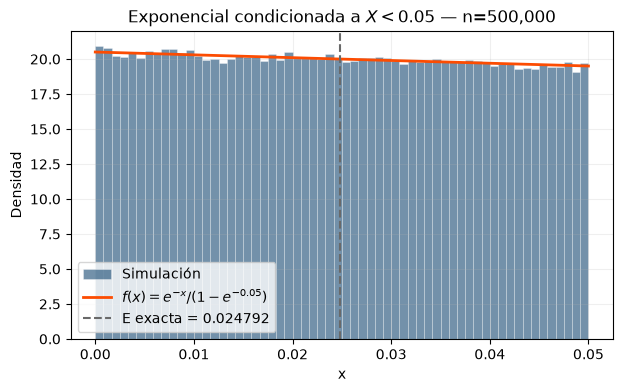

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(X1_grande, bins=60, density=True, color=NAVY, alpha=.55,
        edgecolor="white", linewidth=.4, label="Simulación")
xs = np.linspace(0, A1, 400)
ax.plot(xs, np.exp(-xs) / NORM1, linewidth=2, color=ORANGE, label=r"$f(x)=e^{-x}/(1-e^{-0.05})$")
ax.axvline(exacto1, linestyle="--", color=GREY, label=f"E exacta = {exacto1:.6f}")
ax.set_xlabel("x")
ax.set_ylabel("Densidad")
ax.set_title(f"Exponencial condicionada a $X<0.05$ — n={X1_grande.size:,}")
ax.legend()
ax.grid(alpha=.2)
plt.show()

### Respuesta

**Algoritmo eficiente.** Generar $U\sim\text{Unif}(0,1)$ y devolver $X=-\log\bigl(1-U(1-e^{-0.05})\bigr)$: un uniforme, sin rechazo, contra las $1/(1-e^{-0.05})=\mathbf{20.5}$ exponenciales que exigiría truncar por rechazo.

**Valor exacto.**
$$\boxed{E[X\mid X<0.05]=\frac{1-1.05\,e^{-0.05}}{1-e^{-0.05}}=0.0247916753\ldots}$$

La estimación con las 1000 variables aparece en la primera fila de la tabla de convergencia, junto con su error estándar y su desviación respecto al valor exacto. Nótese que el valor está apenas por debajo de $a/2=0.025$: en un intervalo tan corto la densidad exponencial es casi uniforme.

## 2. Ejercicio 2 — Método de composición

**Enunciado.** Si es fácil generar de cada $F_i$, ¿cómo generar $X$ con
$$F(x)=\sum_{i=1}^{n}p_iF_i(x),\qquad p_i\ge 0,\ \sum_i p_i=1\ ?$$

**Método.** Se interpreta la mezcla como un experimento en dos etapas. Sea $I$ una variable **discreta** con $P(I=i)=p_i$, y dado $I=i$ genérese $X\sim F_i$. Entonces, condicionando en $I$,
$$P(X\le x)=\sum_{i=1}^{n}P(X\le x\mid I=i)\,P(I=i)=\sum_{i=1}^{n}p_iF_i(x)=F(x),$$
que es exactamente la distribución buscada.

**Algoritmo.**

- **Paso 1:** genere $I$ con $P(I=i)=p_i$ (transformación inversa discreta sobre las $p_i$ acumuladas: un uniforme $U_1$).
- **Paso 2:** genere $X\sim F_{I}$ con el método que corresponda a esa componente (un segundo uniforme $U_2$).
- **Paso 3:** devuelva $X$.

El costo es **dos uniformes por variable** y no hay rechazo: toda variable generada se acepta. La utilidad del método es que descompone una $F$ complicada en piezas $F_i$ cada una trivial de invertir.

In [4]:
def generar_composicion(pesos, generadores, n):
    """Paso 1: sortear la componente I con P(I=i)=p_i. Paso 2: generar de F_I."""
    pesos = np.asarray(pesos, dtype=float)
    assert np.isclose(pesos.sum(), 1.0) and np.all(pesos >= 0)
    assert len(pesos) == len(generadores)

    # Paso 1: inversa discreta sobre la acumulada de los pesos.
    cdf = np.round(np.cumsum(pesos), 12)
    idx = np.searchsorted(cdf, rng.random(n), side="left")

    # Paso 2: cada componente se llena en bloque con su propio generador.
    x = np.empty(n, dtype=float)
    for i, gen in enumerate(generadores):
        m = np.count_nonzero(idx == i)
        if m:
            x[idx == i] = gen(m)
    return x

# Verificación del argumento: la frecuencia empírica de I reproduce p_i y la
# mezcla resultante reproduce sum(p_i F_i) punto a punto.
pesos_demo = np.array([0.5, 0.3, 0.2])
Fs_demo = [lambda x: 1 - np.exp(-x),                       # Exp(1)
           lambda x: np.clip(x / 2, 0, 1),                  # Unif(0,2)
           lambda x: stats.gamma.cdf(x, a=3, scale=1.0)]    # Gamma(3,1)
gens_demo = [lambda m: rng.exponential(1.0, m),
             lambda m: rng.uniform(0, 2, m),
             lambda m: rng.gamma(3.0, 1.0, m)]

X2 = generar_composicion(pesos_demo, gens_demo, 400_000)
rejilla = np.linspace(0.05, 8, 12)
F_mezcla = sum(p * F(rejilla) for p, F in zip(pesos_demo, Fs_demo))
F_emp = np.array([(X2 <= x).mean() for x in rejilla])
se_emp = np.sqrt(F_emp * (1 - F_emp) / X2.size)

res2 = pd.DataFrame({"x": rejilla, "F empírica": F_emp, "SE": se_emp,
                     "sum p_i F_i(x)": F_mezcla,
                     "Desviación (SE)": (F_emp - F_mezcla) / se_emp})
display(tabla(res2, 6))
assert np.max(np.abs(res2["Desviación (SE)"])) < 4

x,F empírica,SE,sum p_i F_i(x),Desviación (SE)
0.050000,0.031727,0.000277,0.031889,-0.583842
0.772727,0.393600,0.000772,0.393749,-0.193458
1.495455,0.650617,0.000754,0.650247,0.490896
2.218182,0.822585,0.000604,0.822028,0.921963
2.940909,0.886827,0.000501,0.886279,1.094060
3.663636,0.928925,0.000406,0.928853,0.177857
4.386364,0.956372,0.000323,0.956423,-0.157170
5.109091,0.973853,0.000252,0.973827,0.099848
5.831818,0.984645,0.000194,0.984552,0.477518
6.554545,0.991088,0.000149,0.991021,0.447490


### Respuesta

Generar primero la **etiqueta** $I$ con $P(I=i)=p_i$ y después $X\sim F_I$. Condicionando en $I$ se obtiene $P(X\le x)=\sum_i p_iF_i(x)=F(x)$, de modo que
$$\boxed{X\sim F \iff X\mid I=i\ \sim F_i,\quad P(I=i)=p_i.}$$
Cuesta dos uniformes y no rechaza nada. La tabla confirma la igualdad: la CDF empírica coincide con $\sum_i p_iF_i$ dentro del error Monte Carlo en toda la rejilla.

## 3. Ejercicio 3 — Aplicaciones de la composición

La observación que resuelve los tres incisos es que, para $F_i(x)=x^{i}$ en $[0,1]$, la inversa es inmediata:
$$U=X^{i}\ \Longrightarrow\ X=U^{1/i},$$
es decir, $U^{1/i}$ es el **máximo de $i$ uniformes** independientes.

**(a)** $F(x)=\dfrac{x+x^3+x^5}{3}$ es la mezcla de $x$, $x^3$ y $x^5$ con pesos $\tfrac13$ cada uno:
$$p=(\tfrac13,\tfrac13,\tfrac13),\qquad X=U^{1},\ U^{1/3},\ U^{1/5}.$$
Media exacta: $E[X]=\tfrac13\left(\tfrac12+\tfrac34+\tfrac56\right)=\tfrac{25}{36}$.

**(b)** Separando la $F$ por partes,
$$F(x)=\tfrac13\underbrace{(1-e^{-2x})}_{\text{Exp}(2)}+\tfrac23\underbrace{\min(x,1)}_{\text{Unif}(0,1)},$$
lo que se comprueba en ambos tramos: para $0<x<1$ da $\frac{1-e^{-2x}+2x}{3}$, y para $x>1$ da $\frac{1-e^{-2x}+2}{3}=\frac{3-e^{-2x}}{3}$. Entonces con probabilidad $\tfrac13$ se genera $-\tfrac12\log U$ y con probabilidad $\tfrac23$ se genera $U$. Media exacta: $E[X]=\tfrac13\cdot\tfrac12+\tfrac23\cdot\tfrac12=\tfrac12$.

**(c)** $F(x)=\sum_i \alpha_i x^i$ con $\alpha_i\ge0$ y $\sum_i\alpha_i=1$ ya está escrita como mezcla: se sortea $i$ con probabilidad $\alpha_i$ y se devuelve $U^{1/i}$. Media exacta: $E[X]=\sum_i\alpha_i\frac{i}{i+1}$. Los incisos (a) y (b) del polinomio son el caso particular $\alpha=(\tfrac13,0,\tfrac13,0,\tfrac13)$.

In [5]:
N3 = 400_000

# --- (a) F(x) = (x + x^3 + x^5)/3 --------------------------------------------
pot_a = np.array([1, 3, 5])
pesos_a = np.full(3, 1 / 3)
gens_a = [(lambda i: (lambda m: rng.random(m) ** (1 / i)))(i) for i in pot_a]
Xa = generar_composicion(pesos_a, gens_a, N3)
Fa = lambda x: (np.asarray(x, float) + np.asarray(x, float) ** 3 + np.asarray(x, float) ** 5) / 3
media_a = np.sum(pesos_a * pot_a / (pot_a + 1))
assert np.isclose(media_a, 25 / 36)

# --- (b) mezcla de Exp(2) y Unif(0,1) ----------------------------------------
pesos_b = np.array([1 / 3, 2 / 3])
gens_b = [lambda m: rng.exponential(0.5, m), lambda m: rng.random(m)]
Xb = generar_composicion(pesos_b, gens_b, N3)
def Fb(x):
    x = np.asarray(x, float)
    return np.where(x < 1, (1 - np.exp(-2 * x) + 2 * x) / 3, (3 - np.exp(-2 * x)) / 3)
# La descomposición debe reproducir la F del enunciado en ambos tramos.
_x = np.linspace(0, 8, 20_001)
assert np.max(np.abs(Fb(_x) - ((1 / 3) * (1 - np.exp(-2 * _x)) + (2 / 3) * np.minimum(_x, 1.0)))) < 1e-12
media_b = 0.5

# --- (c) F(x) = sum alpha_i x^i ----------------------------------------------
alpha = np.array([0.15, 0.25, 0.10, 0.30, 0.20])
pot_c = np.arange(1, len(alpha) + 1)
assert np.isclose(alpha.sum(), 1.0) and np.all(alpha >= 0)
gens_c = [(lambda i: (lambda m: rng.random(m) ** (1 / i)))(i) for i in pot_c]
Xc = generar_composicion(alpha, gens_c, N3)
Fc = lambda x: sum(a * np.asarray(x, float) ** i for a, i in zip(alpha, pot_c))
media_c = np.sum(alpha * pot_c / (pot_c + 1))

filas = []
for nombre, X, F, exacto in [("(a) (x+x^3+x^5)/3", Xa, Fa, media_a),
                             ("(b) Exp(2) + Unif(0,1)", Xb, Fb, media_b),
                             ("(c) sum alpha_i x^i", Xc, Fc, media_c)]:
    est, se = X.mean(), se_media(X)
    ks = stats.kstest(X, F)
    filas.append({"Inciso": nombre, "E[X] MC": est, "SE": se, "E[X] exacto": exacto,
                  "Desviación (SE)": z_desviacion(est, exacto, se),
                  "KS D": ks.statistic, "KS p": ks.pvalue})
res3 = pd.DataFrame(filas)
display(tabla(res3, 6))
assert np.all(res3["KS p"] > 0.01)

Inciso,E[X] MC,SE,E[X] exacto,Desviación (SE),KS D,KS p
(a) (x+x^3+x^5)/3,0.694784,0.000409,0.694444,0.831145,0.001604,0.254592
"(b) Exp(2) + Unif(0,1)",0.500694,0.000591,0.500000,1.173969,0.000879,0.916705
(c) sum alpha_i x^i,0.723872,0.000369,0.723333,1.460903,0.001264,0.544560


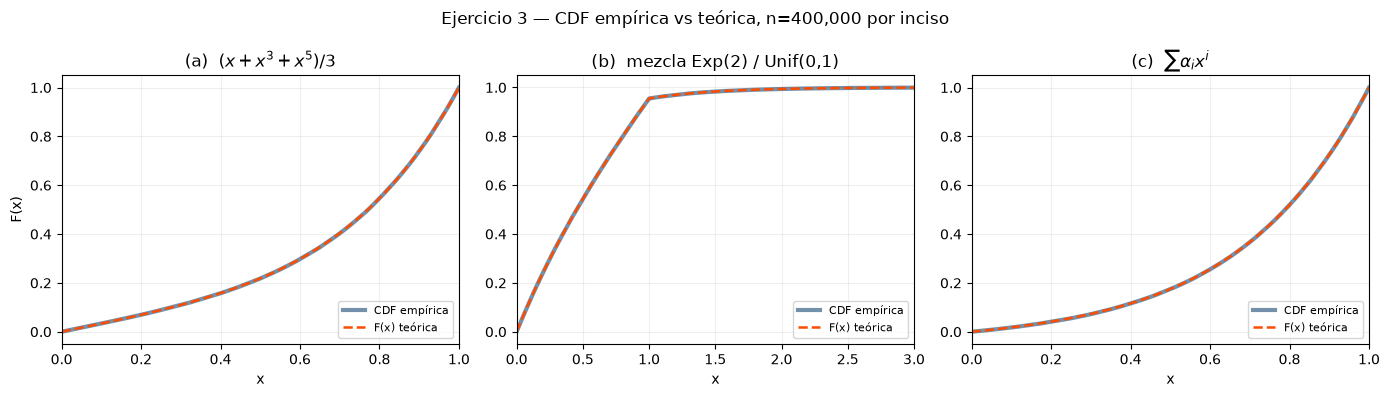

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
paneles = [("(a)  $(x+x^3+x^5)/3$", Xa, Fa, 0, 1),
           ("(b)  mezcla Exp(2) / Unif(0,1)", Xb, Fb, 0, 3),
           ("(c)  $\\sum\\alpha_i x^i$", Xc, Fc, 0, 1)]
for ax, (titulo, X, F, lo, hi) in zip(axes, paneles):
    xs = np.linspace(lo, hi, 500)
    Xo = np.sort(X)
    emp = np.arange(1, Xo.size + 1) / Xo.size
    paso = max(1, Xo.size // 2000)
    ax.plot(Xo[::paso], emp[::paso], linewidth=3, alpha=.55, color=NAVY, label="CDF empírica")
    ax.plot(xs, F(xs), linestyle="--", linewidth=1.8, color=ORANGE, label="F(x) teórica")
    ax.set_xlim(lo, hi)
    ax.set_title(titulo)
    ax.set_xlabel("x")
    ax.grid(alpha=.2)
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("F(x)")
fig.suptitle(f"Ejercicio 3 — CDF empírica vs teórica, n={N3:,} por inciso")
plt.tight_layout()
plt.show()

### Respuesta

**(a)** Sortear $i\in\{1,3,5\}$ con probabilidad $\tfrac13$ cada uno y devolver $\boxed{X=U^{1/i}}$. Media exacta $E[X]=\tfrac{25}{36}=0.6944\overline{4}$.

**(b)** Con probabilidad $\tfrac13$ devolver una $\text{Exp}(2)$, es decir $\boxed{X=-\tfrac12\log U}$; con probabilidad $\tfrac23$ devolver $\boxed{X=U}$. Media exacta $E[X]=\tfrac12$.

**(c)** Sortear $i$ con probabilidad $\alpha_i$ y devolver $\boxed{X=U^{1/i}}$, el máximo de $i$ uniformes. Media exacta $E[X]=\sum_i\alpha_i\frac{i}{i+1}$; con el $\alpha$ concreto usado arriba vale $0.723\overline{3}$.

En los tres casos la media Monte Carlo cae dentro del error estándar del valor exacto y la prueba de Kolmogórov–Smirnov contra la $F$ del enunciado no se rechaza, lo que confirma que la mezcla generada es la distribución pedida y no sólo comparte su media.

## 4. Ejercicio 4 — Riesgo agregado de una cartera de seguros

**Enunciado.** $M=1000$ asegurados; cada uno reclama el próximo mes de forma independiente con probabilidad $p=0.05$. Los montos son $\text{Exp}$ de media $\$800$ e independientes. Estimar por simulación
$$P(S>50{,}000),\qquad S=\sum_{k=1}^{M}I_k\,C_k .$$

**Método.** Dos hechos exactos permiten simular sin recorrer los 1000 asegurados uno por uno:

1. $N=\sum_k I_k\sim\text{Binomial}(1000,\,0.05)$, porque los $I_k$ son Bernoulli independientes con la misma $p$.
2. Dado $N=n$, la suma de $n$ exponenciales i.i.d. de media $\mu$ es exactamente $\text{Gamma}(n,\,\mu)$.

Por tanto cada réplica cuesta **dos sorteos** (una binomial y una gamma) en vez de 2000. Ambos pasos son exactos, no aproximaciones; el notebook lo verifica contra una simulación literal asegurado por asegurado.

**Valor exacto.** Condicionando en $N$,
$$P(S>c)=\sum_{n=1}^{M}\binom{M}{n}p^{n}(1-p)^{M-n}\;P\bigl(\text{Gamma}(n,\mu)>c\bigr),$$
suma finita evaluable a precisión de máquina. Como referencia, $E[S]=Mp\mu=\$40{,}000$ y
$$\operatorname{Var}(S)=E[N]\operatorname{Var}(C)+\operatorname{Var}(N)E[C]^2=50(800^2)+47.5(800^2)=62{,}400{,}000,$$
de donde $\sigma_S=\$7{,}899.37$ y el umbral queda a $1.266\sigma$ de la media.

In [7]:
M4, P4, MU4, UMBRAL4 = 1_000, 0.05, 800.0, 50_000.0

# --- Valor exacto: mezcla binomial de colas gamma -----------------------------
n_grid = np.arange(0, M4 + 1)
pmf_N = stats.binom.pmf(n_grid, M4, P4)
cola_gamma = np.where(n_grid == 0, 0.0,
                      stats.gamma.sf(UMBRAL4, a=np.maximum(n_grid, 1), scale=MU4))
exacto4 = float(np.sum(pmf_N * cola_gamma))
assert np.isclose(pmf_N.sum(), 1.0)

ES4 = M4 * P4 * MU4
VarS4 = M4 * P4 * (2 * MU4**2) - M4 * (P4 * MU4) ** 2   # ley de varianza total
assert np.isclose(VarS4, 50 * MU4**2 + 47.5 * MU4**2)
sdS4 = math.sqrt(VarS4)

# --- Simulación eficiente: N binomial, luego una gamma ------------------------
R4 = 400_000
N4 = rng.binomial(M4, P4, R4)
S4 = np.where(N4 > 0, rng.gamma(np.maximum(N4, 1), MU4, R4), 0.0)
p4 = (S4 > UMBRAL4).mean()
se4 = se_proporcion(p4, R4)

# --- Simulación literal: 1000 asegurados por réplica, por bloques -------------
R4_lit, BLOQUE = 40_000, 4_000
excede_lit, S_lit_media = 0, 0.0
for inicio in range(0, R4_lit, BLOQUE):
    ind = rng.random((BLOQUE, M4)) < P4                 # I_k por asegurado
    montos = rng.exponential(MU4, size=(BLOQUE, M4))    # C_k por asegurado
    s = (ind * montos).sum(axis=1)
    excede_lit += np.count_nonzero(s > UMBRAL4)
    S_lit_media += s.sum()
p4_lit = excede_lit / R4_lit
se4_lit = se_proporcion(p4_lit, R4_lit)
S_lit_media /= R4_lit

# --- Aproximación normal, para dimensionar el sesgo por asimetría -------------
p4_normal = float(stats.norm.sf(UMBRAL4, ES4, sdS4))

res4 = pd.DataFrame([
    {"Método": f"Binomial-Gamma (R={R4:,})", "P(S>50,000)": p4, "SE": se4,
     "Exacto": exacto4, "Desviación (SE)": z_desviacion(p4, exacto4, se4)},
    {"Método": f"Literal, 1000 asegurados (R={R4_lit:,})", "P(S>50,000)": p4_lit, "SE": se4_lit,
     "Exacto": exacto4, "Desviación (SE)": z_desviacion(p4_lit, exacto4, se4_lit)},
    {"Método": "Aproximación normal", "P(S>50,000)": p4_normal, "SE": np.nan,
     "Exacto": exacto4, "Desviación (SE)": np.nan},
])
display(tabla(res4, 6))

res4b = pd.DataFrame([
    {"Cantidad": "E[N]", "MC": N4.mean(), "SE": se_media(N4), "Exacto": M4 * P4},
    {"Cantidad": "E[S]", "MC": S4.mean(), "SE": se_media(S4), "Exacto": ES4},
    {"Cantidad": "sd(S)", "MC": S4.std(ddof=1), "SE": np.nan, "Exacto": sdS4},
    {"Cantidad": "E[S] simulación literal", "MC": S_lit_media, "SE": np.nan, "Exacto": ES4},
])
res4b["Desviación (SE)"] = [z_desviacion(r.MC, r.Exacto, r.SE) if np.isfinite(r.SE) else np.nan
                            for r in res4b.itertuples()]
display(tabla(res4b, 4))

Método,"P(S>50,000)",SE,Exacto,Desviación (SE)
"Binomial-Gamma (R=400,000)",0.106862,0.000488,0.107098,-0.481502
"Literal, 1000 asegurados (R=40,000)",0.108850,0.001557,0.107098,1.125249
Aproximación normal,0.102770,nan,0.107098,nan


Cantidad,MC,SE,Exacto,Desviación (SE)
E[N],50.0113,0.0109,50.0000,1.0395
E[S],"40,010.5814",12.4909,"40,000.0000",0.8471
sd(S),"7,899.9419",nan,"7,899.3671",nan
E[S] simulación literal,"39,975.7245",nan,"40,000.0000",nan


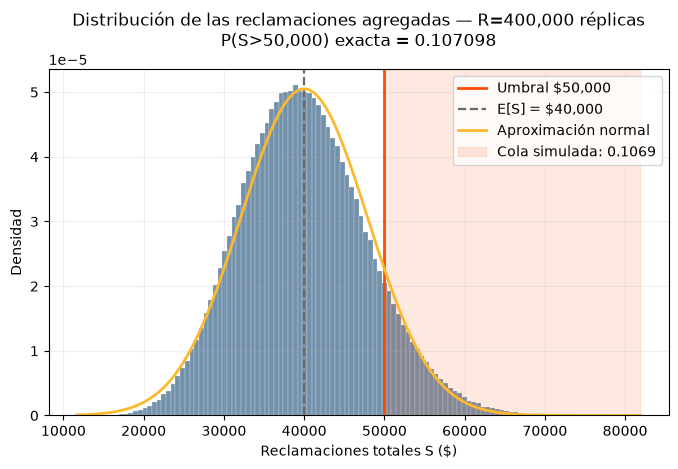

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(S4, bins=120, density=True, color=NAVY, alpha=.55, edgecolor="white", linewidth=.3)
ax.axvline(UMBRAL4, color=ORANGE, linewidth=2, label=f"Umbral \\$50,000")
ax.axvline(ES4, color=GREY, linestyle="--", linewidth=1.6, label=f"E[S] = \\${ES4:,.0f}")
xs = np.linspace(S4.min(), S4.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, ES4, sdS4), color=YELLOW, linewidth=2,
        label="Aproximación normal")
ax.axvspan(UMBRAL4, S4.max(), color=ORANGE, alpha=.12,
           label=f"Cola simulada: {p4:.4f}")
ax.set_xlabel("Reclamaciones totales S (\\$)")
ax.set_ylabel("Densidad")
ax.set_title(f"Distribución de las reclamaciones agregadas — R={R4:,} réplicas\n"
             f"P(S>50,000) exacta = {exacto4:.6f}")
ax.legend()
ax.grid(alpha=.2)
plt.show()

### Respuesta

$$\boxed{P(S>50{,}000)=0.10709770\ldots\approx 10.7\%}$$

Las dos simulaciones —la eficiente Binomial–Gamma con 400,000 réplicas y la literal que recorre los 1000 asegurados— caen dentro del error Monte Carlo del valor exacto, lo que confirma que el atajo $S\mid N=n\sim\text{Gamma}(n,800)$ no introduce sesgo.

La aproximación normal da $10.28\%$ y **subestima** el riesgo: $S$ es una suma compuesta con cola derecha pesada, y precisamente en la cola es donde la aproximación falla. Ése es el argumento a favor de simular en lugar de recurrir al Teorema del Límite Central: el umbral de interés está a $1.27\sigma$ de la media, justo donde la asimetría pesa.